# Control Validation — Real Home Assistant Trace vs Synthetic Control Devices

This notebook compares a real Raspberry Pi Home Assistant Core control-automation workload trace against the synthetic control-oriented device profiles.



In [ ]:
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from google.colab import files
from sklearn.metrics.pairwise import cosine_similarity

warnings.filterwarnings("ignore")

## Upload real Home Assistant perf CSV and synthetic CSV files

In [ ]:
uploaded = files.upload()

print("Uploaded files:")
for f in uploaded:
    print("-", f)

print("\nCSV files in session:")
for f in sorted(os.listdir()):
    if f.endswith(".csv"):
        print("-", f)

Saving medical_monitor_hpc_20251014_133716.csv to medical_monitor_hpc_20251014_133716.csv
Saving real_homeassistant_control_perf_30ms.csv to real_homeassistant_control_perf_30ms.csv
Saving smart_agriculture_hpc_20251016_230252.csv to smart_agriculture_hpc_20251016_230252.csv
Saving smart_thermostat_hpc_20251014_143742.csv to smart_thermostat_hpc_20251014_143742.csv
Uploaded files:
- medical_monitor_hpc_20251014_133716.csv
- real_homeassistant_control_perf_30ms.csv
- smart_agriculture_hpc_20251016_230252.csv
- smart_thermostat_hpc_20251014_143742.csv

CSV files in session:
- medical_monitor_hpc_20251014_133716.csv
- real_homeassistant_control_perf_30ms.csv
- smart_agriculture_hpc_20251016_230252.csv
- smart_thermostat_hpc_20251014_143742.csv


## Detect files automatically

In [ ]:
def first_match(substrings):
    for sub in substrings:
        matches = [f for f in os.listdir() if sub.lower() in f.lower() and f.endswith(".csv")]
        if matches:
            return matches[0]
    return None

real_file = first_match([
    "real_homeassistant_control_perf",
    "homeassistant",
    "ha_control",
    "real_control",
    "control_perf"
])

synthetic_files = {
    "Smart Thermostat": first_match(["smart_thermostat", "thermostat"]),
    "Smart Agriculture": first_match(["smart_agriculture", "agriculture"]),
    "Medical Monitor": first_match(["medical_monitor", "medical"]),
}

print("Real file:", real_file)
for k, v in synthetic_files.items():
    print(k, "=>", v)

if real_file is None:
    raise FileNotFoundError("Could not find the real Home Assistant control perf CSV.")

missing = [k for k, v in synthetic_files.items() if v is None]
if missing:
    raise FileNotFoundError(f"Missing synthetic files: {missing}")

Real file: real_homeassistant_control_perf_30ms.csv
Smart Thermostat => smart_thermostat_hpc_20251014_143742.csv
Smart Agriculture => smart_agriculture_hpc_20251016_230252.csv
Medical Monitor => medical_monitor_hpc_20251014_133716.csv


## Parse the real `perf stat -x ';' -I 30` file

In [ ]:
def to_float(x):
    x = str(x).strip().replace(",", "")
    if x in ["", "<not counted>", "<not supported>", "not counted", "not supported", "<not"]:
        return np.nan
    try:
        return float(x)
    except:
        return np.nan

def parse_perf_csv(path):
    event_map = {
        "cycles": "cycles",
        "cpu-cycles": "cycles",
        "instructions": "instructions",
        "cache-references": "cache-references",
        "cache-misses": "cache-misses",
    }

    rows = []

    with open(path, "r", errors="ignore") as f:
        for line in f:
            line = line.strip()

            if not line or line.startswith("#"):
                continue

            parts = [p.strip() for p in line.split(";")] if ";" in line else line.split()

            if len(parts) < 3:
                continue

            time_val = to_float(parts[0])
            count_val = to_float(parts[1])

            event = None
            for p in parts:
                if p in event_map:
                    event = event_map[p]
                    break

            if event and not np.isnan(time_val) and not np.isnan(count_val):
                rows.append({"time_interval": time_val, "event": event, "value": count_val})

    long_df = pd.DataFrame(rows)

    if long_df.empty:
        raise ValueError("No perf rows parsed. Check the real CSV format.")

    pivot = (
        long_df
        .pivot_table(index="time_interval", columns="event", values="value", aggfunc="sum")
        .reset_index()
        .sort_values("time_interval")
    )

    return pivot

def perf_to_hw_schema(perf_df):
    out = pd.DataFrame()
    out["timestamp"] = perf_df["time_interval"]
    out["hw_cpu_cycles"] = pd.to_numeric(perf_df.get("cycles"), errors="coerce")
    out["hw_instructions_retired"] = pd.to_numeric(perf_df.get("instructions"), errors="coerce")
    out["hw_cache_references"] = pd.to_numeric(perf_df.get("cache-references"), errors="coerce")
    out["cache_misses_raw"] = pd.to_numeric(perf_df.get("cache-misses"), errors="coerce")

    out["hw_instructions_per_cycle"] = (
        out["hw_instructions_retired"] / out["hw_cpu_cycles"].replace(0, np.nan)
    )

    out["hw_cache_miss_rate"] = (
        out["cache_misses_raw"] / out["hw_cache_references"].replace(0, np.nan)
    )

    return out.replace([np.inf, -np.inf], np.nan).dropna()

def load_real_trace(path):
    try:
        df = pd.read_csv(path)
        if "hw_cpu_cycles" in df.columns and "hw_instructions_per_cycle" in df.columns:
            print("Real file is already in hw_* schema.")
            return df
    except Exception:
        pass

    print("Parsing raw perf output...")
    perf_df = parse_perf_csv(path)
    print("Parsed perf shape:", perf_df.shape)
    display(perf_df.head())

    clean = perf_to_hw_schema(perf_df)
    return clean

real_clean = load_real_trace(real_file)

print("Cleaned real Home Assistant trace:", real_clean.shape)
display(real_clean.head())
display(real_clean.describe().T)

Parsing raw perf output...
Parsed perf shape: (1965, 5)


event,time_interval,cache-misses,cache-references,cycles,instructions
0,0.030145,351463.0,10334192.0,35687588.0,24968572.0
1,0.060753,355438.0,11747352.0,38908947.0,27348349.0
2,0.094750,506823.0,13644022.0,51618379.0,30074453.0
3,0.125158,590730.0,18221188.0,63371401.0,40703646.0
4,0.158648,555877.0,15570399.0,58413256.0,34444685.0


Cleaned real Home Assistant trace: (1965, 7)


,timestamp,hw_cpu_cycles,hw_instructions_retired,hw_cache_references,cache_misses_raw,hw_instructions_per_cycle,hw_cache_miss_rate
0,0.030145,35687588.0,24968572.0,10334192.0,351463.0,0.699643,0.034010
1,0.060753,38908947.0,27348349.0,11747352.0,355438.0,0.702881,0.030257
2,0.094750,51618379.0,30074453.0,13644022.0,506823.0,0.582631,0.037146
3,0.125158,63371401.0,40703646.0,18221188.0,590730.0,0.642303,0.032420
4,0.158648,58413256.0,34444685.0,15570399.0,555877.0,0.589672,0.035701


,count,mean,std,min,25%,50%,75%,max
timestamp,1965.0,3.032785e+01,1.753419e+01,0.030145,15.142774,30.339617,4.550156e+01,6.065132e+01
hw_cpu_cycles,1965.0,5.559608e+06,9.935394e+06,336665.000000,398458.000000,581607.000000,5.852851e+06,7.312348e+07
hw_instructions_retired,1965.0,2.647215e+06,4.812996e+06,224636.000000,250770.000000,326742.000000,2.683432e+06,4.943389e+07
hw_cache_references,1965.0,1.299257e+06,2.321291e+06,101376.000000,114327.000000,152258.000000,1.335718e+06,2.128975e+07
cache_misses_raw,1965.0,5.302551e+04,9.485517e+04,3255.000000,3783.000000,4765.000000,5.295900e+04,5.907300e+05
hw_instructions_per_cycle,1965.0,5.571629e-01,8.364473e-02,0.283399,0.483166,0.575201,6.333027e-01,9.207528e-01
hw_cache_miss_rate,1965.0,3.442814e-02,6.206700e-03,0.015922,0.031770,0.032834,3.821672e-02,1.191563e-01


## Load synthetic control datasets

In [ ]:
def load_synthetic(path):
    df = pd.read_csv(path)

    if "workload_intensity" in df.columns:
        df = df[df["workload_intensity"] > 10].copy()

    for c in df.columns:
        if c.startswith("hw_"):
            df[c] = pd.to_numeric(df[c], errors="coerce")

    return df.replace([np.inf, -np.inf], np.nan)

synthetic_data = {}

for device, path in synthetic_files.items():
    synthetic_data[device] = load_synthetic(path)
    print(device, synthetic_data[device].shape)

display(synthetic_data["Smart Thermostat"].head())

Smart Thermostat (20000, 31)
Smart Agriculture (20000, 37)
Medical Monitor (20000, 31)


,timestamp,workload_state,workload_intensity,workload_raw,hw_cpu_cycles,hw_instructions_retired,hw_instructions_per_cycle,hw_branch_instructions,hw_branch_miss_rate,hw_cache_references,...,hvac_mode,learning_enabled,current_temperature,target_temperature,humidity_level,occupancy_detected,outdoor_temperature,energy_usage_kwh,away_mode,comfort_profile
0,2025-10-14 14:27:41.434385,0,23.636223,709.086678,1547380,1553620,1.004033,78980,0.041783,142300,...,heat,1,21.466673,22.0,46,1,15.000000,2.3,0,1
1,2025-10-14 14:27:41.464452,0,23.569556,707.086678,1887351,1394288,0.738754,90695,0.028271,156492,...,heat,1,21.598404,22.0,48,1,15.000000,2.3,0,1
2,2025-10-14 14:27:41.494518,0,23.769556,713.086678,1559538,1487941,0.954091,96546,0.036749,182244,...,heat,1,21.628837,22.0,49,1,15.000000,2.3,0,1
3,2025-10-14 14:27:41.524584,0,23.769556,713.086678,1532236,1244723,0.812357,89452,0.032375,141088,...,heat,1,21.500285,22.0,49,1,15.000000,2.3,0,1
4,2025-10-14 14:27:41.554651,2,23.569556,707.086678,1902768,1289591,0.677745,85824,0.028384,177708,...,heat,1,21.354001,22.0,49,1,15.470322,2.3,0,1


##  Select shared comparison features

In [ ]:
candidate_features = [
    "hw_cpu_cycles",
    "hw_instructions_retired",
    "hw_cache_references",
    "hw_instructions_per_cycle",
    "hw_cache_miss_rate",
]

shared_features = [
    f for f in candidate_features
    if f in real_clean.columns and all(f in df.columns for df in synthetic_data.values())
]

ratio_features = [
    f for f in ["hw_instructions_per_cycle", "hw_cache_miss_rate"]
    if f in shared_features
]

print("Shared features:", shared_features)
print("Ratio features:", ratio_features)

assert len(shared_features) >= 2, "Too few shared features."
assert len(ratio_features) >= 1, "No ratio features found."

Shared features: ['hw_cpu_cycles', 'hw_instructions_retired', 'hw_cache_references', 'hw_instructions_per_cycle', 'hw_cache_miss_rate']
Ratio features: ['hw_instructions_per_cycle', 'hw_cache_miss_rate']


## Similarity and feature comparison

In [ ]:
def log_profile(df, features):
    vals = df[features].mean(numeric_only=True).reindex(features).astype(float)
    vals = vals.replace([np.inf, -np.inf], np.nan).fillna(0.0)
    return np.log1p(np.maximum(vals.values, 0))

def raw_profile(df, features):
    vals = df[features].mean(numeric_only=True).reindex(features).astype(float)
    vals = vals.replace([np.inf, -np.inf], np.nan).fillna(0.0)
    return vals.values

def safe_cosine(a, b):
    a = np.asarray(a, dtype=float).reshape(1, -1)
    b = np.asarray(b, dtype=float).reshape(1, -1)

    if np.linalg.norm(a) == 0 or np.linalg.norm(b) == 0:
        return np.nan

    return float(cosine_similarity(a, b)[0, 0])

real_log = log_profile(real_clean, shared_features)
real_ratio = raw_profile(real_clean, ratio_features)

sim_rows = []
comp_rows = []

for device, df in synthetic_data.items():
    synth_log = log_profile(df, shared_features)
    synth_ratio = raw_profile(df, ratio_features)

    log_cos = safe_cosine(real_log, synth_log)
    ratio_cos = safe_cosine(real_ratio, synth_ratio)

    sim_rows.append({
        "synthetic_device": device,
        "real_reference": "Home Assistant control-automation workload",
        "log_mean_cosine_shared_features": log_cos,
        "ratio_only_cosine": ratio_cos,
        "real_rows": len(real_clean),
        "synthetic_active_rows": len(df)
    })

    for feature in shared_features:
        real_mean = real_clean[feature].mean()
        synth_mean = df[feature].mean()

        pct_diff = np.nan if abs(real_mean) < 1e-12 else ((synth_mean - real_mean) / abs(real_mean)) * 100

        comp_rows.append({
            "synthetic_device": device,
            "feature": feature,
            "feature_type": "ratio/derived" if feature in ratio_features else "raw count",
            "real_mean": real_mean,
            "synthetic_mean": synth_mean,
            "percent_difference_vs_real": pct_diff
        })

similarity_df = pd.DataFrame(sim_rows)
comparison_df = pd.DataFrame(comp_rows)

print("Similarity summary:")
display(similarity_df.round(6))

print("Feature-level comparison:")
display(comparison_df.round(6))

Similarity summary:


,synthetic_device,real_reference,log_mean_cosine_shared_features,ratio_only_cosine,real_rows,synthetic_active_rows
0,Smart Thermostat,Home Assistant control-automation workload,0.998791,0.999958,1965,20000
1,Smart Agriculture,Home Assistant control-automation workload,0.998929,0.999986,1965,20000
2,Medical Monitor,Home Assistant control-automation workload,0.998832,0.999950,1965,20000


Feature-level comparison:


,synthetic_device,feature,feature_type,real_mean,synthetic_mean,percent_difference_vs_real
0,Smart Thermostat,hw_cpu_cycles,raw count,5.559608e+06,1.934930e+06,-65.196642
1,Smart Thermostat,hw_instructions_retired,raw count,2.647215e+06,1.707122e+06,-35.512511
2,Smart Thermostat,hw_cache_references,raw count,1.299257e+06,1.800186e+05,-86.144495
3,Smart Thermostat,hw_instructions_per_cycle,ratio/derived,5.571630e-01,8.909200e-01,59.902904
4,Smart Thermostat,hw_cache_miss_rate,ratio/derived,3.442800e-02,4.688500e-02,36.183060
5,Smart Agriculture,hw_cpu_cycles,raw count,5.559608e+06,2.544900e+06,-54.225186
6,Smart Agriculture,hw_instructions_retired,raw count,2.647215e+06,2.265374e+06,-14.424238
7,Smart Agriculture,hw_cache_references,raw count,1.299257e+06,2.489816e+05,-80.836610
8,Smart Agriculture,hw_instructions_per_cycle,ratio/derived,5.571630e-01,8.994090e-01,61.426611
9,Smart Agriculture,hw_cache_miss_rate,ratio/derived,3.442800e-02,5.075000e-02,47.408821


##  Interpretation summary

In [ ]:
summary_rows = []

for device in synthetic_data.keys():
    sub = comparison_df[comparison_df["synthetic_device"] == device]

    raw_sub = sub[sub["feature_type"] == "raw count"]
    ratio_sub = sub[sub["feature_type"] == "ratio/derived"]

    raw_avg_abs_pct = raw_sub["percent_difference_vs_real"].abs().mean()
    ratio_avg_abs_pct = ratio_sub["percent_difference_vs_real"].abs().mean()

    sim_row = similarity_df[similarity_df["synthetic_device"] == device].iloc[0]
    ratio_cos = sim_row["ratio_only_cosine"]

    if ratio_cos >= 0.95:
        interp = "Strong behavioural support"
    elif ratio_cos >= 0.85:
        interp = "Moderate behavioural support"
    else:
        interp = "Weak behavioural support"

    summary_rows.append({
        "synthetic_device": device,
        "log_mean_cosine_shared_features": sim_row["log_mean_cosine_shared_features"],
        "ratio_only_cosine": ratio_cos,
        "avg_abs_percent_diff_raw_counts": raw_avg_abs_pct,
        "avg_abs_percent_diff_ratio_features": ratio_avg_abs_pct,
        "recommended_interpretation": interp
    })

interpretation_df = pd.DataFrame(summary_rows)
display(interpretation_df.round(6))

,synthetic_device,log_mean_cosine_shared_features,ratio_only_cosine,avg_abs_percent_diff_raw_counts,avg_abs_percent_diff_ratio_features,recommended_interpretation
0,Smart Thermostat,0.998791,0.999958,62.284549,48.042982,Strong behavioural support
1,Smart Agriculture,0.998929,0.999986,49.828678,54.417716,Strong behavioural support
2,Medical Monitor,0.998832,0.999950,55.111474,48.242101,Strong behavioural support


## Boxplots for ratio features

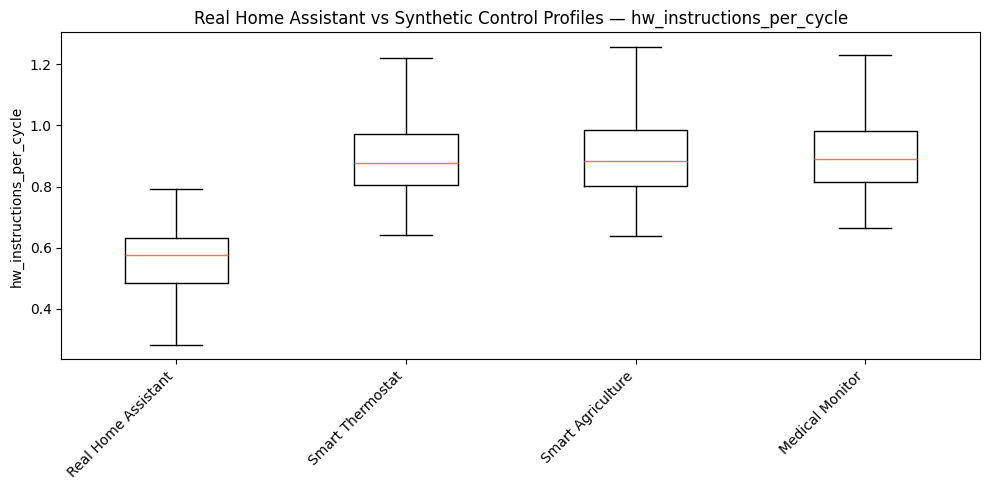

Saved: homeassistant_control_boxplot_hw_instructions_per_cycle.png


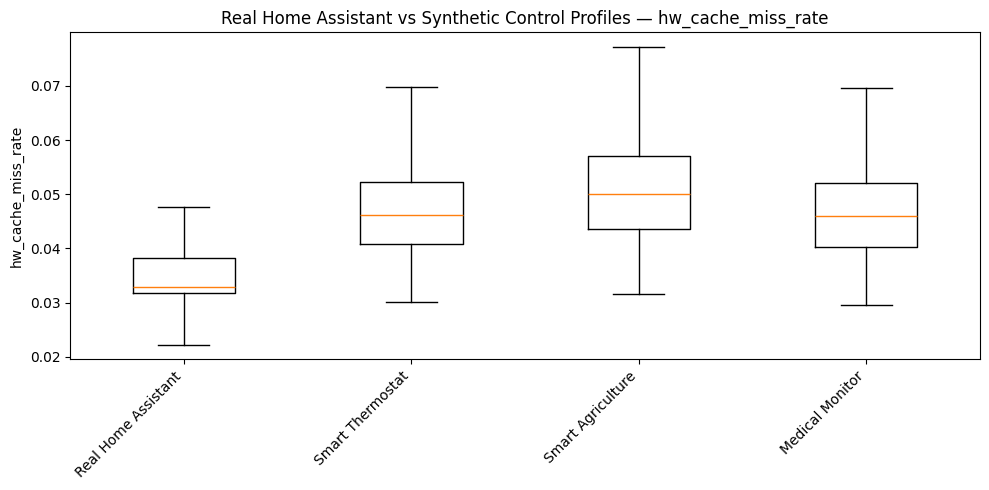

Saved: homeassistant_control_boxplot_hw_cache_miss_rate.png


In [ ]:
for feature in ratio_features:
    data = [real_clean[feature].dropna().values]
    labels = ["Real Home Assistant"]

    for device, df in synthetic_data.items():
        data.append(df[feature].dropna().values)
        labels.append(device)

    plt.figure(figsize=(10, 5))
    plt.boxplot(data, labels=labels, showfliers=False)
    plt.xticks(rotation=45, ha="right")
    plt.ylabel(feature)
    plt.title(f"Real Home Assistant vs Synthetic Control Profiles — {feature}")
    plt.tight_layout()

    fname = f"homeassistant_control_boxplot_{feature}.png"
    plt.savefig(fname, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", fname)